In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    mean_absolute_percentage_error,
    cohen_kappa_score
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

FIG_DIR = os.path.join("figures")
os.makedirs(FIG_DIR, exist_ok=True)

DATA_PATH = os.path.join("..", "data", "processed", "cleaned_dataset.csv")
df = pd.read_csv(DATA_PATH)
print("Processed dataset loaded successfully.")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Processed dataset loaded successfully.
Dataset Shape: 7308 rows, 13 columns


In [15]:
# --- DEFINING PREDICTOR SETS (X) ---
# set 1: for linear Models (no Elevation_m; drop 1 dummy to prevent dummy variable trap)
linear_features = [
    "Rainfall_mm",
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Location_Marikina",
    "Location_Pasig",
    "Location_Quezon City",  # Manila as reference
]
X_linear = df[linear_features].copy()

# set 2: For CART Tree Models (with Elevation_m and all 4 city dummies)
cart_features = [
    "Rainfall_mm",
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Elevation_m",
    "Location_Manila",
    "Location_Marikina",
    "Location_Pasig",
    "Location_Quezon City",
]
X_cart = df[cart_features].copy()

# --- DEFINING TARGETS (y) ---
y_reg = df["FloodDepth_m"].copy() 
y_clf = df["RiskLevel"].copy() 

# --- TRAIN-TEST SPLITS (80/20) ---
# regression Splits
X_train_lin_reg, X_test_lin_reg, y_train_reg, y_test_reg = train_test_split(
    X_linear, y_reg, test_size=0.20, random_state=42
)
X_train_cart_reg, X_test_cart_reg, _, _ = train_test_split(
    X_cart, y_reg, test_size=0.20, random_state=42
)

# classification splits
X_train_lin_clf, X_test_lin_clf, y_train_clf, y_test_clf = train_test_split(
    X_linear, y_clf, test_size=0.20, random_state=42, stratify=y_clf
) # stratified for balance
X_train_cart_clf, X_test_cart_clf, _, _ = train_test_split(
    X_cart, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

print(f"Linear Feature Set ({len(linear_features)}): {linear_features}")
print(f"CART Feature Set ({len(cart_features)}): {cart_features}")
print(f"Training samples: {X_train_lin_reg.shape[0]} | Testing samples: {X_test_lin_reg.shape[0]}")
print(f"RiskLevel Class Balance in y_train_clf:\n{y_train_clf.value_counts(normalize=True).mul(100).round(2)}")

Linear Feature Set (6): ['Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct', 'Location_Marikina', 'Location_Pasig', 'Location_Quezon City']
CART Feature Set (8): ['Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct', 'Elevation_m', 'Location_Manila', 'Location_Marikina', 'Location_Pasig', 'Location_Quezon City']
Training samples: 5846 | Testing samples: 1462
RiskLevel Class Balance in y_train_clf:
RiskLevel
Low         98.49
Moderate     0.86
High         0.65
Name: proportion, dtype: float64


In [16]:
# Standardization (For linear models only)

scaler_lin_reg = StandardScaler()
scaler_lin_clf = StandardScaler()

# fit on training data
X_train_lin_reg_scaled = pd.DataFrame(
    scaler_lin_reg.fit_transform(X_train_lin_reg), 
    columns=linear_features,
    index=X_train_lin_reg.index
)

# transform/use the learned mean and sd on test data
X_test_lin_reg_scaled = pd.DataFrame(
    scaler_lin_reg.transform(X_test_lin_reg), 
    columns=linear_features,
    index=X_test_lin_reg.index
)

X_train_lin_clf_scaled = pd.DataFrame(
    scaler_lin_clf.fit_transform(X_train_lin_clf),
    columns=linear_features,
    index=X_train_lin_clf.index
)
X_test_lin_clf_scaled = pd.DataFrame(
    scaler_lin_clf.transform(X_test_lin_clf),
    columns=linear_features,
    index=X_test_lin_clf.index
)

scaler_summary_df = pd.DataFrame(
    {
        "Feature": linear_features,
        "Mean": scaler_lin_reg.mean_.round(4),
        "Std Dev": np.sqrt(scaler_lin_reg.var_).round(4),
    }
)
print("StandardScaler successfully fitted strictly on X_train partitions.")
display(scaler_summary_df)

StandardScaler successfully fitted strictly on X_train partitions.


,Feature,Mean,Std Dev
0,Rainfall_mm,10.0438,7.1629
1,WaterLevel_m,1.2633,0.9081
2,SoilMoisture_pct,15.1815,6.0049
3,Location_Marikina,0.2504,0.4333
4,Location_Pasig,0.2494,0.4327
5,Location_Quezon City,0.2508,0.4335


In [17]:
# --- BASELINE MULTIPLE LINEAR REGRESSION ---
# Predictor Set: Scaled features, no Elevation_m, Manila as reference
# Target: FloodDepth_m (continuous, meters)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_lin_reg_scaled, y_train_reg)

y_pred_lin_reg = lin_reg_model.predict(X_test_lin_reg_scaled)

# regression evaluation metrics
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin_reg)
rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin_reg))
r2_lin = r2_score(y_test_reg, y_pred_lin_reg)
mape_lin = mean_absolute_percentage_error(y_test_reg, y_pred_lin_reg) * 100

# masked non-zero eval (active: FloodDepth > 0.0 m)
non_zero_mask_reg = y_test_reg > 0.0
if non_zero_mask_reg.sum() > 0:
    mape_lin_nonzero = mean_absolute_percentage_error(
        y_test_reg[non_zero_mask_reg], 
        y_pred_lin_reg[non_zero_mask_reg]
    ) * 100
else:
    mape_lin_nonzero = np.nan

print("---BASELINE: MULTIPLE LINEAR REGRESSION RESULTS---")
print(f"Mean Absolute Error (MAE):      {mae_lin:.4f} m")
print(f"Root Mean Squared Error (RMSE): {rmse_lin:.4f} m")
print(f"R-squared (R2 Score):           {r2_lin:.4f}")
print(f"MAPE (Global):                  {mape_lin:.2f}%")
print(f"MAPE (>0 m):                    {mape_lin_nonzero:.2f}%")

# coefficients and intercept
coef_df = pd.DataFrame({
    'Feature': linear_features,
    'Coefficient': lin_reg_model.coef_.round(4)
}).sort_values(by='Coefficient', ascending=False)

print(f"Intercept: {lin_reg_model.intercept_:.4f}")
print("\n--- Model Coefficients ---")
display(coef_df)

---BASELINE: MULTIPLE LINEAR REGRESSION RESULTS---
Mean Absolute Error (MAE):      0.0505 m
Root Mean Squared Error (RMSE): 0.0890 m
R-squared (R2 Score):           0.1066
MAPE (Global):                  19613817577579764.00%
MAPE (>0 m):                    64.36%
Intercept: 0.0169

--- Model Coefficients ---


,Feature,Coefficient
0,Rainfall_mm,0.0496
1,WaterLevel_m,0.0222
3,Location_Marikina,0.0040
4,Location_Pasig,0.0038
5,Location_Quezon City,0.0038
2,SoilMoisture_pct,0.0006


In [18]:
# ---CART DECISION TREE REGRESSOR (PRIMARY MODEL)---
# Predictor Set: Full feature set (WITH Elevation_m and all Location dummies)
# Hyperparameters: max_depth=4, min_samples_leaf=20 
# Target: FloodDepth_m (continuous, meters)

tree_reg_model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
tree_reg_model.fit(X_train_cart_reg, y_train_reg)

y_pred_tree_reg = tree_reg_model.predict(X_test_cart_reg)

mae_tree = mean_absolute_error(y_test_reg, y_pred_tree_reg)
rmse_tree = np.sqrt(mean_squared_error(y_test_reg, y_pred_tree_reg))
r2_tree = r2_score(y_test_reg, y_pred_tree_reg)
mape_tree = mean_absolute_percentage_error(y_test_reg, y_pred_tree_reg) * 100

if non_zero_mask_reg.sum() > 0:
    mape_tree_nonzero = (
        mean_absolute_percentage_error(
            y_test_reg[non_zero_mask_reg], y_pred_tree_reg[non_zero_mask_reg]
        )
        * 100
    )
else:
    mape_tree_nonzero = np.nan

print("---PRIMARY MODEL: CART DECISION TREE REGRESSOR---")
print(f"Mean Absolute Error (MAE):      {mae_tree:.4f} m")
print(f"Root Mean Squared Error (RMSE): {rmse_tree:.4f} m")
print(f"R-squared (R2 Score):           {r2_tree:.4f}")
print(f"MAPE (Global):                  {mape_tree:.2f}%")
print(f"MAPE (> 0 m):                   {mape_tree_nonzero:.2f}%")

# Regression Model Comparison Summary Table
comparison_reg_df = pd.DataFrame({
    "Model": ["Multiple Linear Regression (Baseline)", "Decision Tree Regressor (CART Primary)"],
    "Predictor Set Used": ["Without Elevation (Collinearity Control)", "With Elevation (All Features)"],
    "MAE (m)": [mae_lin, mae_tree],
    "RMSE (m)": [rmse_lin, rmse_tree],
    "R² Score": [r2_lin, r2_tree],
    'MAPE (Global %)': [mape_lin, mape_tree],
    'MAPE (> 0.0 m %)': [mape_lin_nonzero, mape_tree_nonzero]
})

print("\n--- Regression Model Comparison Summary ---")
display(comparison_reg_df.round(4))

---PRIMARY MODEL: CART DECISION TREE REGRESSOR---
Mean Absolute Error (MAE):      0.0010 m
Root Mean Squared Error (RMSE): 0.0116 m
R-squared (R2 Score):           0.9848
MAPE (Global):                  0.18%
MAPE (> 0 m):                   13.90%

--- Regression Model Comparison Summary ---


,Model,Predictor Set Used,MAE (m),RMSE (m),R² Score,MAPE (Global %),MAPE (> 0.0 m %)
0,Multiple Linear Regression (Baseline),Without Elevation (Collinearity Control),0.0505,0.0890,0.1066,1.961382e+16,64.3642
1,Decision Tree Regressor (CART Primary),With Elevation (All Features),0.0010,0.0116,0.9848,1.806000e-01,13.8956


Saved feature importance plot to: figures\cart_regressor_feature_importance.png


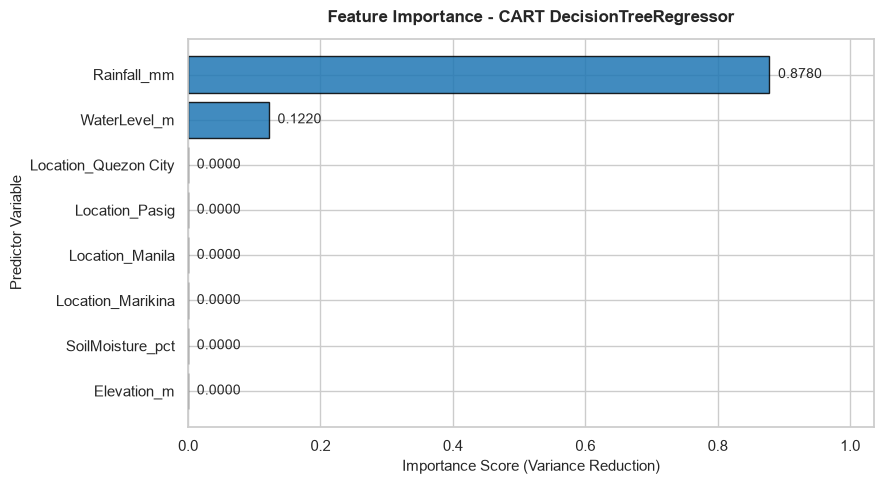


--- Feature Importance Table ---


,Feature,Importance
0,Rainfall_mm,0.878014
1,WaterLevel_m,0.121986
2,Elevation_m,0.000000
3,SoilMoisture_pct,0.000000
4,Location_Manila,0.000000
5,Location_Marikina,0.000000
6,Location_Quezon City,0.000000
7,Location_Pasig,0.000000


In [19]:
# ---FEATURE IMPORTANCE - REGRESSOR TREE---
# Metric: Variance Reduction (reduction in squared error)

importances = tree_reg_model.feature_importances_
feature_names = cart_features

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# horizontal bar chart
plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='#1f77b4', edgecolor='black', alpha=0.85)
plt.title("Feature Importance - CART DecisionTreeRegressor", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Importance Score (Variance Reduction)", fontsize=11)
plt.ylabel("Predictor Variable", fontsize=11)

max_imp = max(fi_df['Importance']) if max(fi_df['Importance']) > 0 else 1.0
plt.xlim(0, max_imp * 1.18)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max_imp * 0.015), 
        bar.get_y() + bar.get_height() / 2, 
        f"{width:.4f}", 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='medium'
    )

plt.tight_layout()

# notebooks/figures/
fi_export_path = os.path.join(FIG_DIR, "cart_regressor_feature_importance.png")
plt.savefig(fi_export_path, dpi=300, bbox_inches='tight')
print(f"Saved feature importance plot to: {fi_export_path}")
plt.show()

# table
print("\n--- Feature Importance Table ---")
display(fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True))

Saved decision tree diagram to: figures\cart_regressor_tree_diagram.png


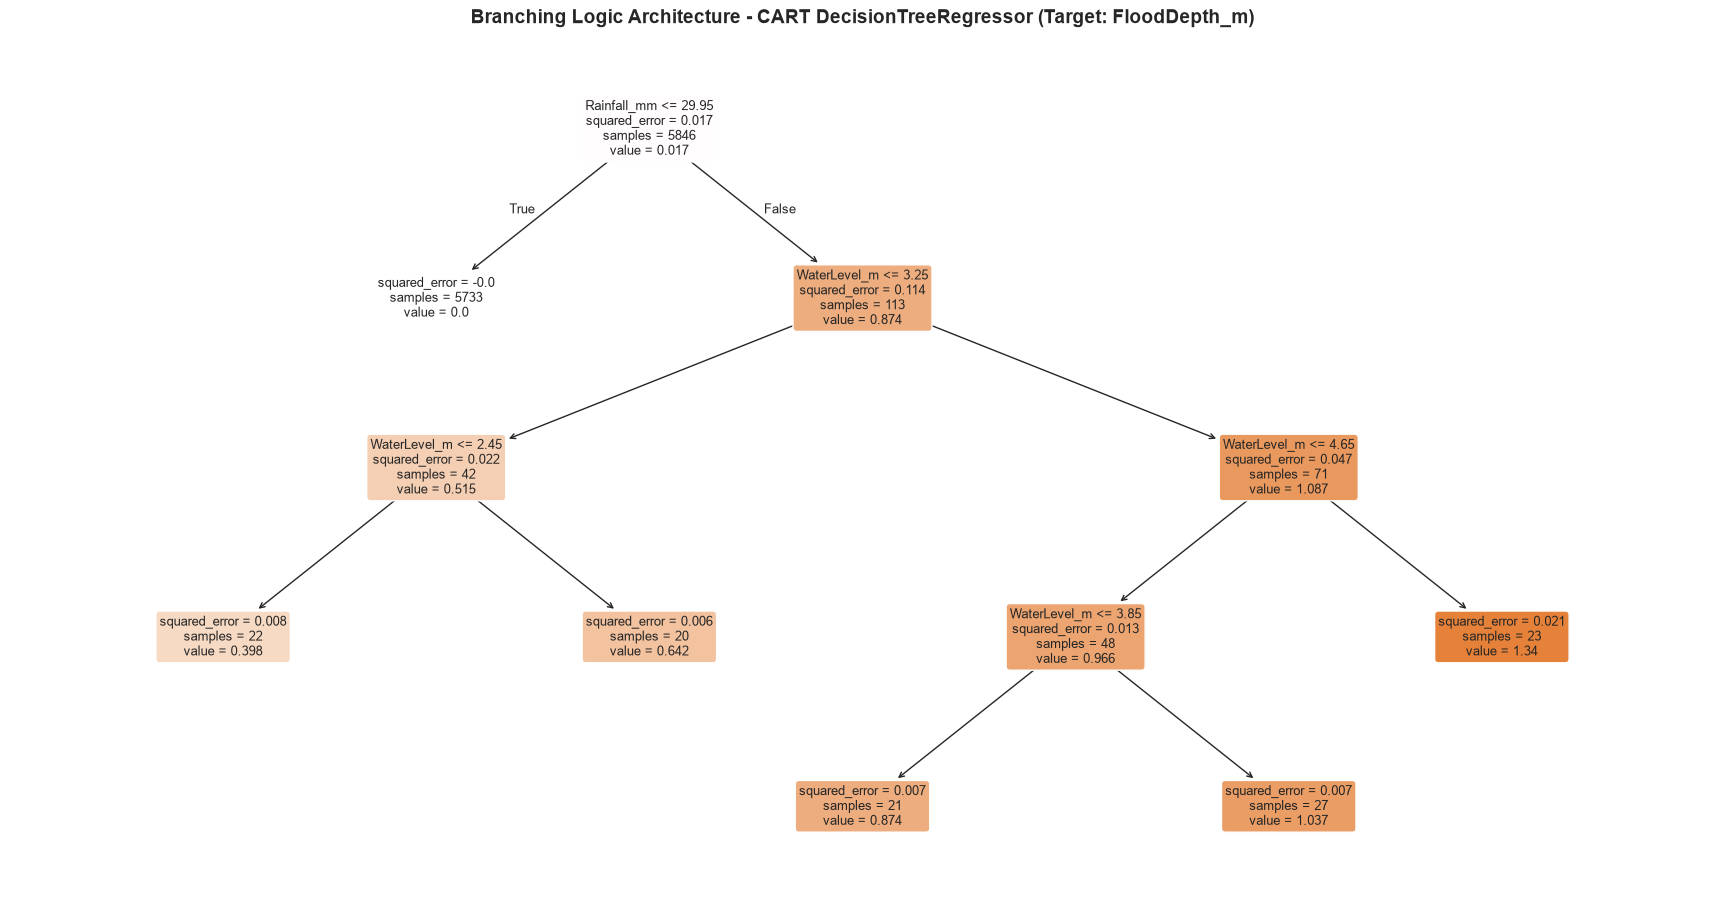

In [20]:
# ---DECISION TREE REGRESSOR DECISION LOGIC ARCHITECTURE VISUALIZATION---

plt.figure(figsize=(22, 11))
plot_tree(
    tree_reg_model,
    feature_names=cart_features,
    filled=True,
    rounded=True,
    precision=3,
    fontsize=9
)
plt.title(
    "Branching Logic Architecture - CART DecisionTreeRegressor (Target: FloodDepth_m)", 
    fontsize=14, 
    fontweight='bold', 
    pad=15
)

tree_export_path = os.path.join(FIG_DIR, "cart_regressor_tree_diagram.png")
plt.savefig(tree_export_path, dpi=300, bbox_inches='tight')
print(f"Saved decision tree diagram to: {tree_export_path}")
plt.show()

--- BASELINE: MULTINOMIAL LOGISTIC REGRESSION RESULTS ---
Accuracy:                    0.9884
Macro Precision:             0.7061
Macro Recall:                0.9198 (Priority Metric)
Macro F1-Score:              0.7885
Weighted F1-Score:           0.9898
Quadratic Cohen's Kappa:     0.7902

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      0.99      0.99      1440
    Moderate       0.48      0.77      0.59        13
        High       0.64      1.00      0.78         9

    accuracy                           0.99      1462
   macro avg       0.71      0.92      0.79      1462
weighted avg       0.99      0.99      0.99      1462



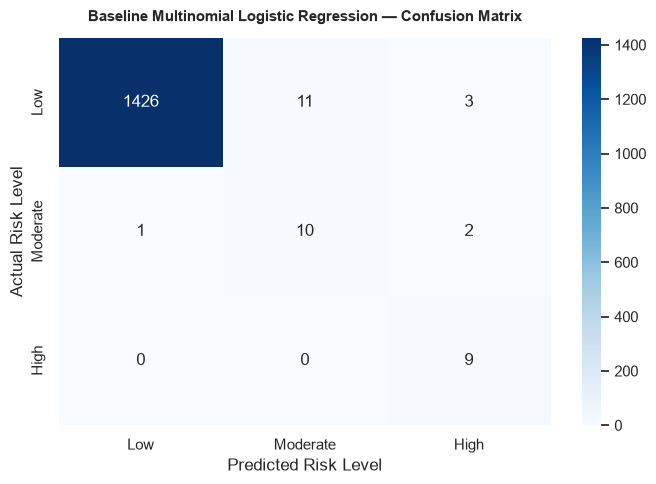

In [21]:
# --- BASELINE MULTINOMIAL LOGISTIC REGRESSION ---
# target: RiskLevel (3 classes: Low, Moderate, High - MGB Tiers)
# predictors: Scaled features, no Elevation_m, Manila as reference

class_labels = ["Low", "Moderate", "High"]

log_reg_model = LogisticRegression(
    class_weight="balanced", 
    max_iter=1000, 
    random_state=42
)
log_reg_model.fit(X_train_lin_clf_scaled, y_train_clf)

y_pred_log_reg = log_reg_model.predict(X_test_lin_clf_scaled)

# --metrics--
acc_log = accuracy_score(y_test_clf, y_pred_log_reg)

# macro average
prec_log_macro = precision_score(y_test_clf, y_pred_log_reg, average="macro", zero_division=0)
rec_log_macro = recall_score(y_test_clf, y_pred_log_reg, average="macro", zero_division=0)
f1_log_macro = f1_score(y_test_clf, y_pred_log_reg, average="macro", zero_division=0)

# weighted average
f1_log_weighted = f1_score(y_test_clf, y_pred_log_reg, average="weighted", zero_division=0)
kappa_log = cohen_kappa_score(y_test_clf, y_pred_log_reg, labels=class_labels, weights="quadratic")

print("--- BASELINE: MULTINOMIAL LOGISTIC REGRESSION RESULTS ---")
print(f"Accuracy:                    {acc_log:.4f}")
print(f"Macro Precision:             {prec_log_macro:.4f}")
print(f"Macro Recall:                {rec_log_macro:.4f} (Priority Metric)")
print(f"Macro F1-Score:              {f1_log_macro:.4f}")
print(f"Weighted F1-Score:           {f1_log_weighted:.4f}")
print(f"Quadratic Cohen's Kappa:     {kappa_log:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_clf, y_pred_log_reg, labels=class_labels, target_names=class_labels, zero_division=0))

# confusion matrix
cm_log = confusion_matrix(y_test_clf, y_pred_log_reg, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_log, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=[f"{c}" for c in class_labels], 
    yticklabels=[f"{c}" for c in class_labels]
)
plt.title("Baseline Multinomial Logistic Regression — Confusion Matrix", fontsize=11, fontweight="bold", pad=12)
plt.ylabel("Actual Risk Level")
plt.xlabel("Predicted Risk Level")
plt.tight_layout()
plt.show()

--- PRIMARY MODEL: CART DECISION TREE CLASSIFIER RESULTS ---
Accuracy:                    0.9952
Macro Precision:             0.8556
Macro Recall:               0.9730 (Priority Metric)
Macro F1-Score:              0.9065
Weighted F1-Score:           0.9956
Quadratic Cohen's Kappa:     0.9336

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      1440
    Moderate       0.67      0.92      0.77        13
        High       0.90      1.00      0.95         9

    accuracy                           1.00      1462
   macro avg       0.86      0.97      0.91      1462
weighted avg       1.00      1.00      1.00      1462

Saved classifier confusion matrix to: figures\cart_classifier_confusion_matrix.png


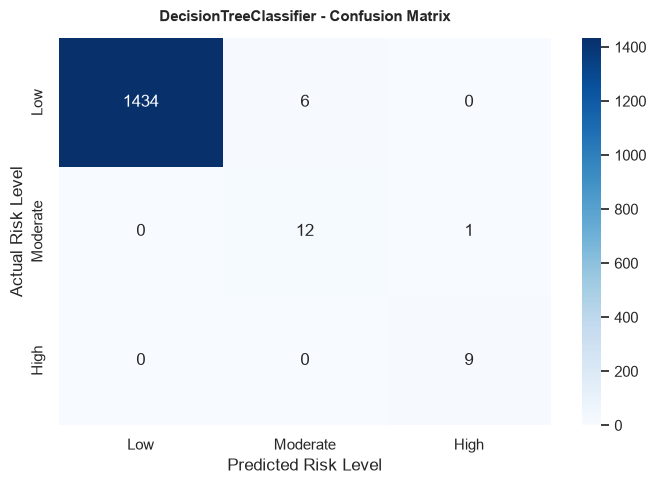

In [22]:
# --- PRIMARY CART DECISION TREE CLASSIFIER ---
# target: RiskLevel (3 classes: Low, Moderate, High - MGB Tiers)
# predictor Set: Full feature set (WITH Elevation_m and all Location dummies)
# hyperparameters: max_depth=4, class_weight="balanced", min_samples_leaf=20

tree_clf_model = DecisionTreeClassifier(
    max_depth=4, class_weight="balanced", min_samples_leaf=20, random_state=42
)
tree_clf_model.fit(X_train_cart_clf, y_train_clf)

y_pred_tree_clf = tree_clf_model.predict(X_test_cart_clf)

# -- metrics --
acc_tree = accuracy_score(y_test_clf, y_pred_tree_clf)

# macro average
prec_tree_macro = precision_score(y_test_clf, y_pred_tree_clf, average="macro", zero_division=0)
rec_tree_macro = recall_score(y_test_clf, y_pred_tree_clf, average="macro", zero_division=0)
f1_tree_macro = f1_score(y_test_clf, y_pred_tree_clf, average="macro", zero_division=0)

# weighted average
f1_tree_weighted = f1_score(y_test_clf, y_pred_tree_clf, average="weighted", zero_division=0)

# quadratic weighted Cohen's Kappa
kappa_tree_clf = cohen_kappa_score(
    y_test_clf, y_pred_tree_clf, labels=class_labels, weights="quadratic"
)

print("--- PRIMARY MODEL: CART DECISION TREE CLASSIFIER RESULTS ---")
print(f"Accuracy:                    {acc_tree:.4f}")
print(f"Macro Precision:             {prec_tree_macro:.4f}")
print(f"Macro Recall:               {rec_tree_macro:.4f} (Priority Metric)")
print(f"Macro F1-Score:              {f1_tree_macro:.4f}")
print(f"Weighted F1-Score:           {f1_tree_weighted:.4f}")
print(f"Quadratic Cohen's Kappa:     {kappa_tree_clf:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_clf, y_pred_tree_clf, labels=class_labels, target_names=class_labels, zero_division=0))

# confusion Matrix
cm_tree = confusion_matrix(y_test_clf, y_pred_tree_clf, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"{c}" for c in class_labels],
    yticklabels=[f"{c}" for c in class_labels],
)
plt.title(
    "DecisionTreeClassifier - Confusion Matrix",
    fontsize=11,
    fontweight="bold",
    pad=12
)
plt.ylabel("Actual Risk Level")
plt.xlabel("Predicted Risk Level")
plt.tight_layout()

cm_export_path = os.path.join(FIG_DIR, "cart_classifier_confusion_matrix.png")
plt.savefig(cm_export_path, dpi=300, bbox_inches="tight")
print(f"Saved classifier confusion matrix to: {cm_export_path}")
plt.show()

In [23]:
# classification Model Comparison Summary Table
comparison_clf_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression (Baseline)",
            "Decision Tree Classifier (CART Primary)",
        ],
        "Predictor Set Used": [
            "Without Elevation (Collinearity Control)",
            "With Elevation (All Features)",
        ],
        "Accuracy": [acc_log, acc_tree],
        "Macro Precision": [prec_log_macro, prec_tree_macro],
        "Macro Recall": [rec_log_macro, rec_tree_macro],
        "Macro F1-Score": [f1_log_macro, f1_tree_macro],
        "Weighted F1-Score": [f1_log_weighted, f1_tree_weighted],
        "Quadratic Kappa": [kappa_log, kappa_tree_clf],
    }
)

print("\n--- Classification Model Comparison Summary ---")
display(comparison_clf_df.round(4))


--- Classification Model Comparison Summary ---


,Model,Predictor Set Used,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Weighted F1-Score,Quadratic Kappa
0,Logistic Regression (Baseline),Without Elevation (Collinearity Control),0.9884,0.7061,0.9198,0.7885,0.9898,0.7902
1,Decision Tree Classifier (CART Primary),With Elevation (All Features),0.9952,0.8556,0.9730,0.9065,0.9956,0.9336


Saved classifier feature importance plot to: figures\cart_classifier_feature_importance.png


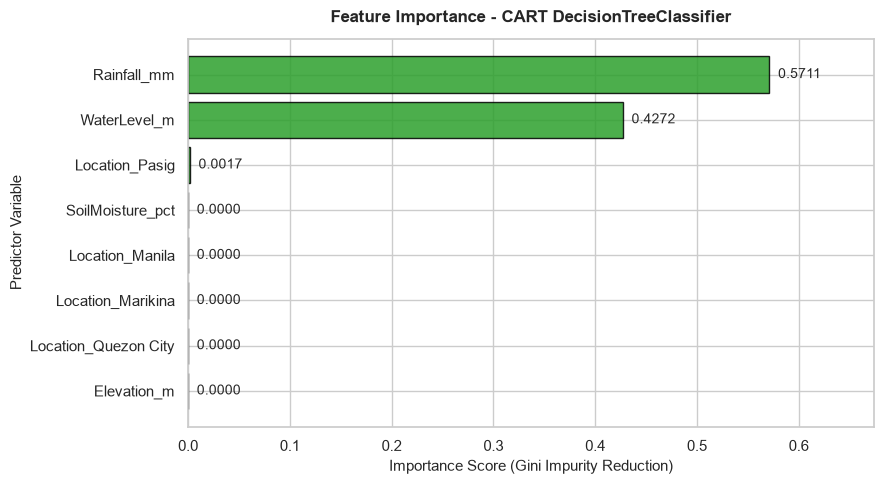


--- Classifier Feature Importance Ranking ---


,Feature,Importance
0,Rainfall_mm,0.571140
1,WaterLevel_m,0.427171
2,Location_Pasig,0.001684
3,SoilMoisture_pct,0.000006
4,Location_Manila,0.000000
5,Location_Marikina,0.000000
6,Location_Quezon City,0.000000
7,Elevation_m,0.000000


In [24]:
# --- FEATURE IMPORTANCE - CART CLASSIFIER ---
# Metric: Gini Impurity Reduction

clf_importances = tree_clf_model.feature_importances_

clf_fi_df = pd.DataFrame({
    'Feature': cart_features,
    'Importance': clf_importances
}).sort_values(by='Importance', ascending=True)

# horizontal bar chart
plt.figure(figsize=(9, 5))
bars = plt.barh(
    clf_fi_df['Feature'], 
    clf_fi_df['Importance'], 
    color='#2ca02c', 
    edgecolor='black', 
    alpha=0.85
)
plt.title("Feature Importance - CART DecisionTreeClassifier", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Importance Score (Gini Impurity Reduction)", fontsize=11)
plt.ylabel("Predictor Variable", fontsize=11)

max_imp = max(clf_fi_df['Importance']) if len(clf_fi_df) > 0 else 1.0
plt.xlim(0, max_imp * 1.18)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max_imp * 0.015), 
        bar.get_y() + bar.get_height() / 2, 
        f"{width:.4f}", 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='medium'
    )

plt.tight_layout()

# notebooks/figures
clf_fi_path = os.path.join(FIG_DIR, "cart_classifier_feature_importance.png")
plt.savefig(clf_fi_path, dpi=300, bbox_inches='tight')
print(f"Saved classifier feature importance plot to: {clf_fi_path}")
plt.show()

# table
print("\n--- Classifier Feature Importance Ranking ---")
display(clf_fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True))

Saved classifier decision tree diagram to: figures\cart_classifier_tree_diagram.png


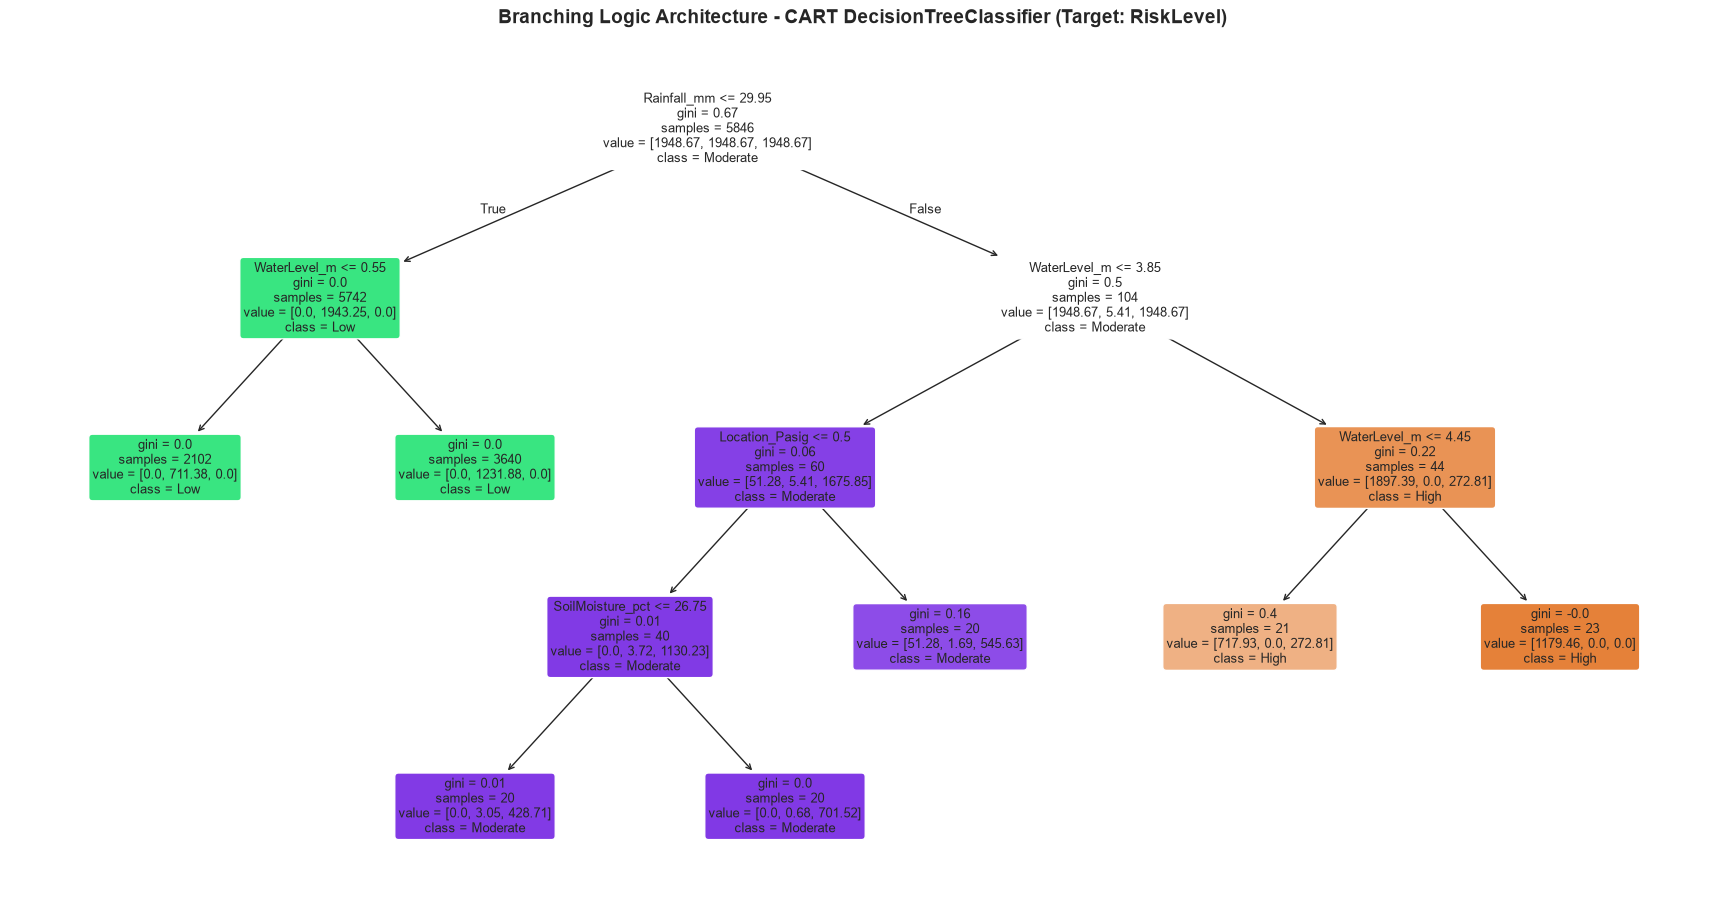

In [25]:
# ---DECISION TREE CLASSIFIER DECISION LOGIC ARCHITECTURE VISUALIZATION---

plt.figure(figsize=(22, 11))
plot_tree(
    tree_clf_model,
    feature_names=cart_features,
    class_names=[str(c) for c in tree_clf_model.classes_],
    filled=True,
    rounded=True,
    precision=2,
    fontsize=9
)
plt.title(
    "Branching Logic Architecture - CART DecisionTreeClassifier (Target: RiskLevel)", 
    fontsize=14, 
    fontweight='bold', 
    pad=15
)

clf_tree_path = os.path.join(FIG_DIR, "cart_classifier_tree_diagram.png")
plt.savefig(clf_tree_path, dpi=300, bbox_inches='tight')
print(f"Saved classifier decision tree diagram to: {clf_tree_path}")
plt.show()

In [26]:
import os
import joblib

MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# models/
joblib.dump(tree_reg_model, os.path.join(MODELS_DIR, "cart_decision_tree_regressor.joblib"))
joblib.dump(tree_clf_model, os.path.join(MODELS_DIR, "cart_decision_tree_classifier.joblib"))
joblib.dump(lin_reg_model, os.path.join(MODELS_DIR, "baseline_linear_regression.joblib"))
joblib.dump(log_reg_model, os.path.join(MODELS_DIR, "baseline_logistic_regression.joblib"))
joblib.dump(scaler_lin_reg, os.path.join(MODELS_DIR, "scaler_linear_features.joblib"))

print("All evaluated models and scalers from Notebook 03 saved to `models/`.")

All evaluated models and scalers from Notebook 03 saved to `models/`.


## Step 3: Model Training & Evaluation Summary

### 1. Feature Scaling / Standardization 
- **Data Leakage Mitigation:**
   - `StandardScaler` is fitted strictly on the 80% training subsets (`X_train_lin`).
   - The learned parameters (mean, sd) are then applied to transform the 20% unseen test subsets (`X_test`). Computing scaling parameters across the entire dataset prior to splitting would constitute information leakage, leading to overly optimistic test metrics.
- **Parametric Sensitivity vs. Tree Invariance:**
   - **Linear Models (MLR & Logistic Regression):** Require Z-score standardization  because coefficient estimation and gradient behavior are sensitive to disparate measurement scales (mm, m, and percentages).
   - **Decision Trees (CART):** Invariant to monotonic feature transformations. CART determines split thresholds via rank-order inequalities, meaning feature scaling yields mathematically identical splits while unnecessarily obscuring the real physical units of the tree diagrams.
- **Input Predictors:** `Rainfall_mm`, `WaterLevel_m`, and `SoilMoisture_pct` were scaled for the linear baselines alongside one-hot location indicators.

### 2. Modeling Strategy and Feature Archi
- **Target Specifications:**
  - **Regression Target:** `FloodDepth_m` (continuous, zero-inflated, measured in meters).
  - **Classification Target:** `RiskLevel` (3-tier ordinal hazard scale: Low < 0.5 m, Moderate 0.5 m <= 1.0 m, High > 1.0 m).
- **Baseline Models (MLR & Logistic Regression):** Trained on 6 scaled predictors (`Rainfall_mm`, `WaterLevel_m`, `SoilMoisture_pct`, and 3 city dummies). `Location_Manila` was omitted as the reference category to prevent dummy variable trap singularity. `Elevation_m` was omitted to resolve perfect multicollinearity.
- **Primary CART Models (DecisionTreeRegressor & DecisionTreeClassifier):** Configured with `max_depth=4` and regularized with `min_samples_leaf=20`. CART retains all 8 features (including `Elevation_m` and all 4 location dummies) due to its non-parametric handling of collinearity.

### 3. Regression Performance Comparison
- **Multiple Linear Regression (Baseline, Scaled Features):**
  - Mean Absolute Error (MAE):      0.0505 m
  - Root Mean Squared Error (RMSE): 0.0890 m
  - R-squared (R2 Score):           0.1066
  - MAPE (Global):                  19613817577579764.00%
  - MAPE (>0 m):                    64.36%
- **CART DecisionTreeRegressor (Primary Model, min_samples_leaf=20):**
  - Mean Absolute Error (MAE):      0.0010 m
  - Root Mean Squared Error (RMSE): 0.0116 m
  - R-squared (R2 Score):           0.9848
  - MAPE (Global):                  0.18%
  - MAPE (> 0 m):                   13.90%
- **Key Observations:** 
  - **Non-Linear Threshold Dynamics:** Multiple Linear Regression failed to capture physical flood behavior (R^2 = 0.1066), suffering from positive baseline puddling (intercept: 0.0169) on completely dry days.
  - **CART Inundation Precision:** CART achieved near-perfect variance explanation (R^2 = 0.9848), dropping MAE to 0.0010 m and reducing relative error on active storm days from 64.36% to 13.90%.
  - **Percentage Error Integrity:** Standard global MAPE is rendered invalid by zero-inflation. The masked non-zero subset (> 0.0 m) provides the definitive stakeholder metric for active inundation error.

### 4. Classification Performance & Reliability Assessment
- **Multinomial Logistic Regression (Baseline, 6 Scaled Features):**
  - Accuracy:                    0.9884
  - Macro Precision:             0.7061
  - Macro Recall:                0.9198 (Priority Metric)
  - Macro F1-Score:              0.7885
  - Weighted F1-Score:           0.9898
  - Quadratic Cohen's Kappa:     0.7902
- **CART DecisionTreeClassifier (Primary Model, 8 Unscaled Features):**
  - Accuracy:                    0.9952
  - Macro Precision:             0.8556
  - Macro Recall:                0.9730 (Priority Metric)
  - Macro F1-Score:              0.9065
  - Weighted F1-Score:           0.9956
  - Quadratic Cohen's Kappa:     0.9336
- **Key Observations:** 
  - **Disaster Hazard Sensitivity:** Both models prioritized recall via balanced class weighting. However, CART reduced false alarms significantly:
    - **High Risk:** Both models achieved 100% recall (9/9). CART increased precision from 0.64 to 0.90.
    - **Moderate Risk:** CART increased recall from 0.77 to 0.92 (12/13) and precision from 0.48 to 0.67.
  - **Ordinal Agreement:** Quadratic Cohen's Kappa reached 0.9336 for CART, confirming that classification errors are rare and restricted exclusively to adjacent hazard categories with zero high-consequence misses.

### 5. Explainability & Visualizations
- **Feature Importance Drivers:**
  - **Regressor:** Inundation depth is governed by `Rainfall_mm` (87.80%) and `WaterLevel_m` (12.20%).
  - **Classifier:** Hazard level transitions are balanced between `Rainfall_mm` (57.11%) and `WaterLevel_m` (42.72%), with marginal contributions from `Location_Pasig` (0.17%).
- **Exported Figures (`notebooks/figures/`):**
  - `cart_regressor_feature_importance.png`
  - `cart_regressor_tree_diagram.png`
  - `cart_classifier_confusion_matrix.png`
  - `cart_classifier_feature_importance.png`
  - `cart_classifier_tree_diagram.png`

### 5. Model Saving & Reuse
- **Evaluated Artifacts Exported:** 
  - To maintain strict experimental reproducibility, the exact model estimators evaluated on the 80/20 split were serialized to `models/` rather than refitting on the full dataset.
  - Exported artifacts include:
    - `cart_decision_tree_regressor.joblib` 
    - `cart_decision_tree_classifier.joblib`
    - `baseline_linear_regression.joblib` & `baseline_logistic_regression.joblib`
    - `scaler_linear_features.joblib` (`StandardScaler` fitted strictly on the 80% training set to prevent data leakage during linear model inference)
- **Downstream Handoff:**
  - `04_export_models.ipynb` ingests these serialized binaries to perform schema validation (`model_features.json`) and run mock inference smoke testing.